# BigQuery COVID-19 Vaccination Search Analysis

## Project Overview
This project analyzes COVID-19 vaccination search interest using a public Google BigQuery dataset.  
The analysis explores global trends and focuses on South Africa search interest over time.

## Dataset
bigquery-public-data.covid19_vaccination_search_insights

## Tools Used
- Google BigQuery
- SQL
- Python
- Pandas
- Matplotlib
- Google Colab

In [2]:
from google.colab import auth
auth.authenticate_user()

In [ ]:
from google.cloud import bigquery

client = bigquery.Client(
    project="project-6d13720b-1cec-430b-923",
    location="US"
)

In [ ]:
query = """
SELECT *
FROM `bigquery-public-data.covid19_vaccination_search_insights.covid19_vaccination_search_insights`
LIMIT 100
"""

df = client.query(query).to_dataframe()
df.head()

,date,country_region,country_region_code,sub_region_1,sub_region_1_code,sub_region_2,sub_region_2_code,sub_region_3,sub_region_3_code,place_id,sni_covid19_vaccination,sni_vaccination_intent,sni_safety_side_effects
0,2022-03-07,United Kingdom,GB,England,GB-ENG,Reigate and Banstead District,None,postal_code,RH1,ChIJ-0EcWdLkdUgRZ1PS4oL4kFo,17.713,4.983,1.209
1,2021-05-24,United Kingdom,GB,England,GB-ENG,Reigate and Banstead District,None,postal_code,RH1,ChIJ-0EcWdLkdUgRZ1PS4oL4kFo,62.944,15.111,13.284
2,2022-05-02,United Kingdom,GB,England,GB-ENG,Reigate and Banstead District,None,postal_code,RH1,ChIJ-0EcWdLkdUgRZ1PS4oL4kFo,19.592,5.689,1.527
3,2023-10-23,United Kingdom,GB,England,GB-ENG,Reigate and Banstead District,None,postal_code,RH1,ChIJ-0EcWdLkdUgRZ1PS4oL4kFo,6.842,1.439,1.247
4,2021-09-06,United Kingdom,GB,England,GB-ENG,Reigate and Banstead District,None,postal_code,RH1,ChIJ-0EcWdLkdUgRZ1PS4oL4kFo,32.471,8.311,4.745


In [ ]:
!pip install google-cloud-bigquery pandas-gbq --quiet

In [ ]:
df.columns

Index(['date', 'country_region', 'country_region_code', 'sub_region_1',
       'sub_region_1_code', 'sub_region_2', 'sub_region_2_code',
       'sub_region_3', 'sub_region_3_code', 'place_id',
       'sni_covid19_vaccination', 'sni_vaccination_intent',
       'sni_safety_side_effects'],
      dtype='object')

In [ ]:
df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     100 non-null    dbdate 
 1   country_region           100 non-null    object 
 2   country_region_code      100 non-null    object 
 3   sub_region_1             100 non-null    object 
 4   sub_region_1_code        100 non-null    object 
 5   sub_region_2             100 non-null    object 
 6   sub_region_2_code        0 non-null      object 
 7   sub_region_3             100 non-null    object 
 8   sub_region_3_code        100 non-null    object 
 9   place_id                 100 non-null    object 
 10  sni_covid19_vaccination  100 non-null    float64
 11  sni_vaccination_intent   100 non-null    float64
 12  sni_safety_side_effects  100 non-null    float64
dtypes: dbdate(1), float64(3), object(9)
memory usage: 10.3+ KB


In [ ]:
query = """
SELECT country_region, SUM(sni_covid19_vaccination) as total_search
FROM `bigquery-public-data.covid19_vaccination_search_insights.covid19_vaccination_search_insights`
GROUP BY country_region
ORDER BY total_search DESC
LIMIT 10
"""

top_countries = client.query(query).to_dataframe()
top_countries

,country_region,total_search
0,United States,4.602702e+07
1,United Kingdom,1.113797e+07
2,Canada,8.406039e+06
3,Australia,6.851877e+06
4,Ireland,1.354395e+05


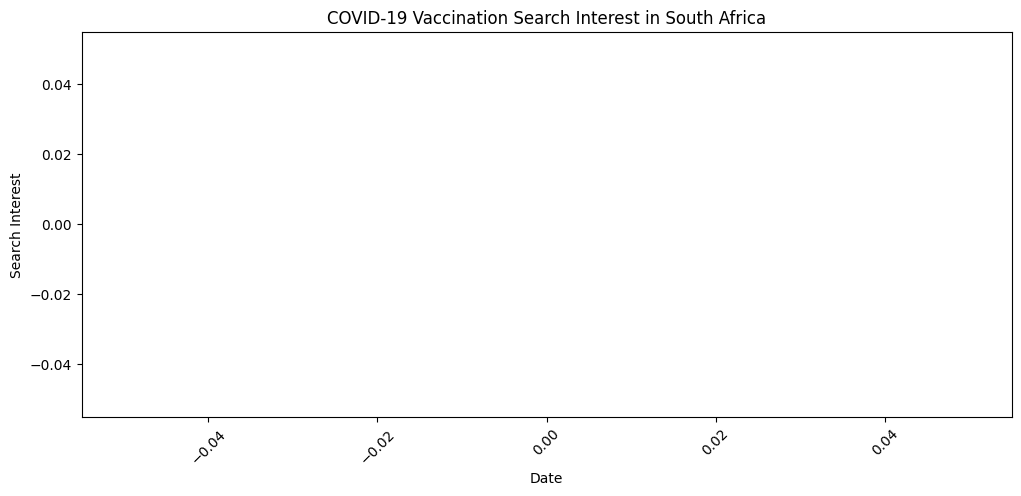

In [ ]:
query = """
SELECT date, sni_covid19_vaccination
FROM `bigquery-public-data.covid19_vaccination_search_insights.covid19_vaccination_search_insights`
WHERE country_region = 'South Africa'
ORDER BY date
"""

za_trends = client.query(query).to_dataframe()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(za_trends['date'], za_trends['sni_covid19_vaccination'])
plt.title("COVID-19 Vaccination Search Interest in South Africa")
plt.xlabel("Date")
plt.ylabel("Search Interest")
plt.xticks(rotation=45)
plt.show()

Sample data (first 5 rows):

Columns in dataset:
Index(['date', 'country_region', 'country_region_code', 'sub_region_1',
       'sub_region_1_code', 'sub_region_2', 'sub_region_2_code',
       'sub_region_3', 'sub_region_3_code', 'place_id',
       'sni_covid19_vaccination', 'sni_vaccination_intent',
       'sni_safety_side_effects'],
      dtype='object')

Top 10 countries by vaccination search interest:
   country_region  total_search
0   United States  4.602702e+07
1  United Kingdom  1.113797e+07
2          Canada  8.406039e+06
3       Australia  6.851877e+06
4         Ireland  1.354395e+05


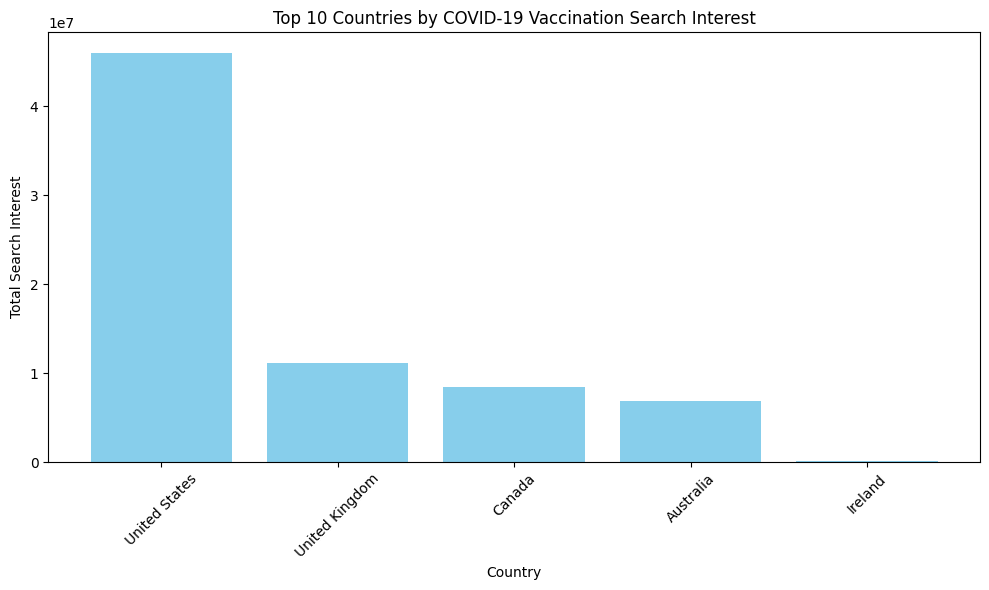

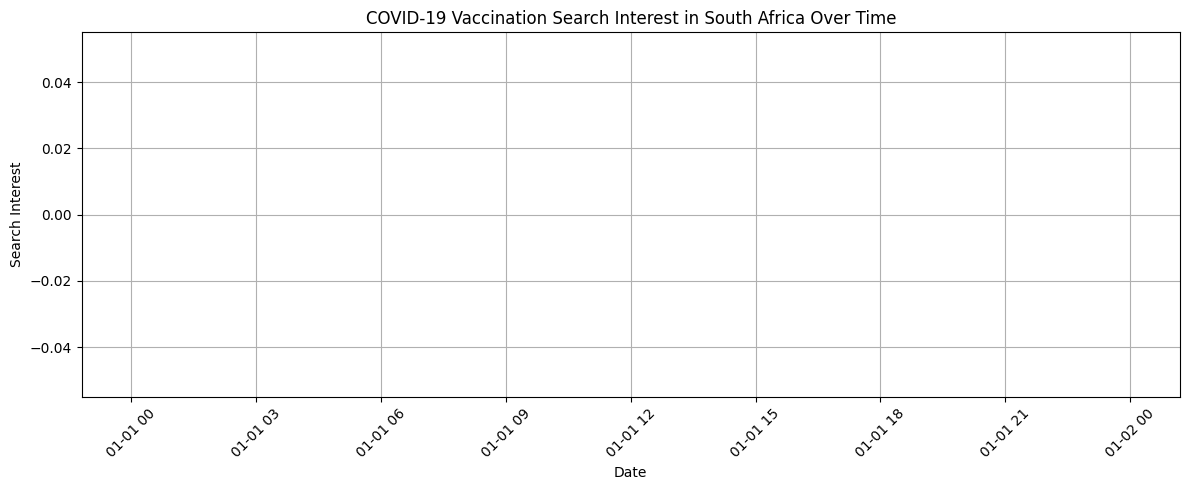


Charts saved as PNG files: 'top_countries_search_interest.png' and 'south_africa_trend.png'


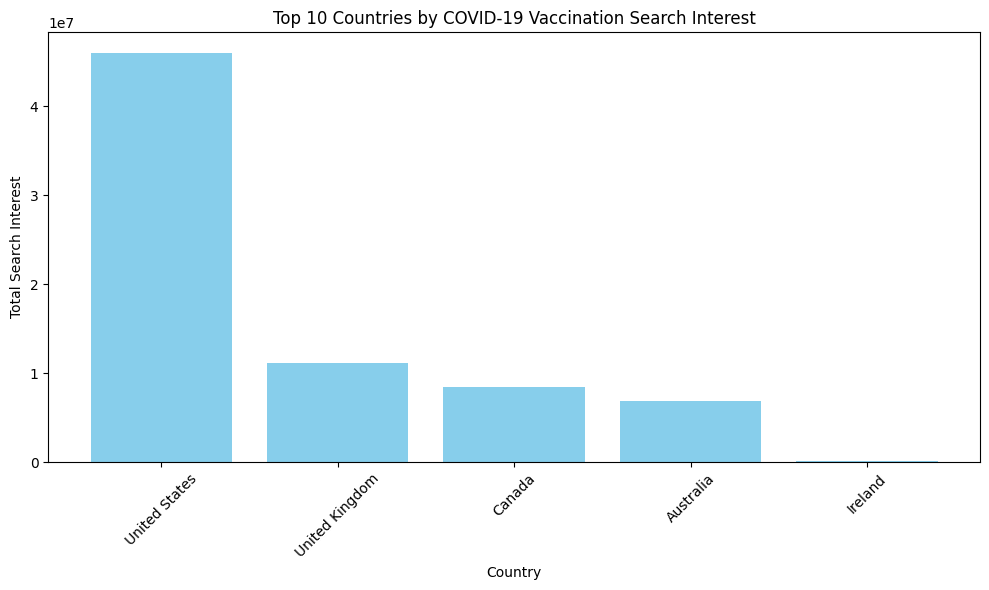

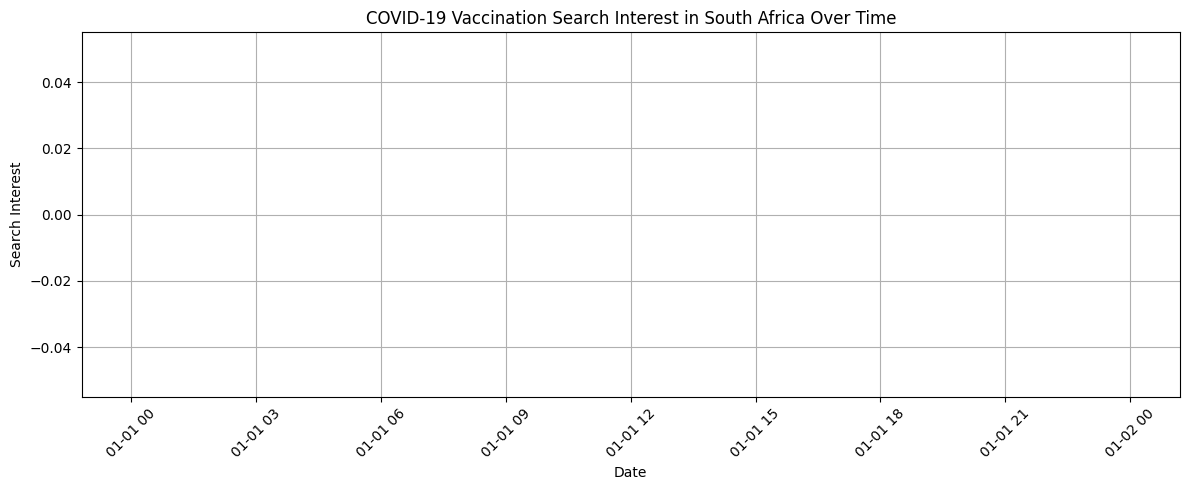

In [ ]:
# ==============================================
# COVID-19 Vaccination Search Insights Analysis
# Colab-ready notebook
# ==============================================

# 1️⃣ Install required packages
!pip install --quiet google-cloud-bigquery pandas matplotlib

# 2️⃣ Authenticate with Google Cloud
from google.colab import auth
auth.authenticate_user()

# 3️⃣ Import libraries
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

# 4️⃣ Create BigQuery client
client = bigquery.Client(
    project="project-6d13720b-1cec-430b-923",
    location="US"
)

# ==============================================
# 5️⃣ Pull sample of dataset
query_sample = """
SELECT *
FROM `bigquery-public-data.covid19_vaccination_search_insights.covid19_vaccination_search_insights`
LIMIT 100
"""

df_sample = client.query(query_sample).to_dataframe()
print("Sample data (first 5 rows):")
df_sample.head()

# Check column names
print("\nColumns in dataset:")
print(df_sample.columns)

# ==============================================
# 6️⃣ Top countries by total vaccination search interest
query_top_countries = """
SELECT country_region, SUM(sni_covid19_vaccination) as total_search
FROM `bigquery-public-data.covid19_vaccination_search_insights.covid19_vaccination_search_insights`
GROUP BY country_region
ORDER BY total_search DESC
LIMIT 10
"""

top_countries = client.query(query_top_countries).to_dataframe()
print("\nTop 10 countries by vaccination search interest:")
print(top_countries)

# Plot top countries
plt.figure(figsize=(10,6))
plt.bar(top_countries['country_region'], top_countries['total_search'], color='skyblue')
plt.title("Top 10 Countries by COVID-19 Vaccination Search Interest")
plt.xlabel("Country")
plt.ylabel("Total Search Interest")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==============================================
# 7️⃣ Trend of vaccination search interest in South Africa
query_sa_trends = """
SELECT date, sni_covid19_vaccination
FROM `bigquery-public-data.covid19_vaccination_search_insights.covid19_vaccination_search_insights`
WHERE country_region = 'South Africa'
ORDER BY date
"""

za_trends = client.query(query_sa_trends).to_dataframe()

# Convert date column to datetime
za_trends['date'] = pd.to_datetime(za_trends['date'])

# Plot trend
plt.figure(figsize=(12,5))
plt.plot(za_trends['date'], za_trends['sni_covid19_vaccination'], color='green', marker='o', markersize=3)
plt.title("COVID-19 Vaccination Search Interest in South Africa Over Time")
plt.xlabel("Date")
plt.ylabel("Search Interest")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# ==============================================
# 8️⃣ Optional: Save plots for reports or portfolio
plt.figure(figsize=(10,6))
plt.bar(top_countries['country_region'], top_countries['total_search'], color='skyblue')
plt.title("Top 10 Countries by COVID-19 Vaccination Search Interest")
plt.xlabel("Country")
plt.ylabel("Total Search Interest")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("top_countries_search_interest.png")

plt.figure(figsize=(12,5))
plt.plot(za_trends['date'], za_trends['sni_covid19_vaccination'], color='green', marker='o', markersize=3)
plt.title("COVID-19 Vaccination Search Interest in South Africa Over Time")
plt.xlabel("Date")
plt.ylabel("Search Interest")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig("south_africa_trend.png")

print("\nCharts saved as PNG files: 'top_countries_search_interest.png' and 'south_africa_trend.png'")

## Key Insights

- Vaccination search interest varies across countries
- Some regions show higher public interest in COVID-19 vaccines
- South Africa search trends change over time
- BigQuery allows fast analysis of large datasets

## Skills Demonstrated

- SQL querying in BigQuery  
- Cloud-based data analysis  
- Python data analysis  
- Data visualization  
- Working with public datasets